In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("StudentsPerformance.csv")
print(df.head())
print(df.shape)        
print(df.columns)      

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'w

In [8]:
# Group by gender and calculate mean of all three subjects
gender_avg = df.groupby('gender')[['math score', 'reading score', 'writing score']].mean().round(2)

print("Average Scores by Gender:")
print(gender_avg)

Average Scores by Gender:
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31


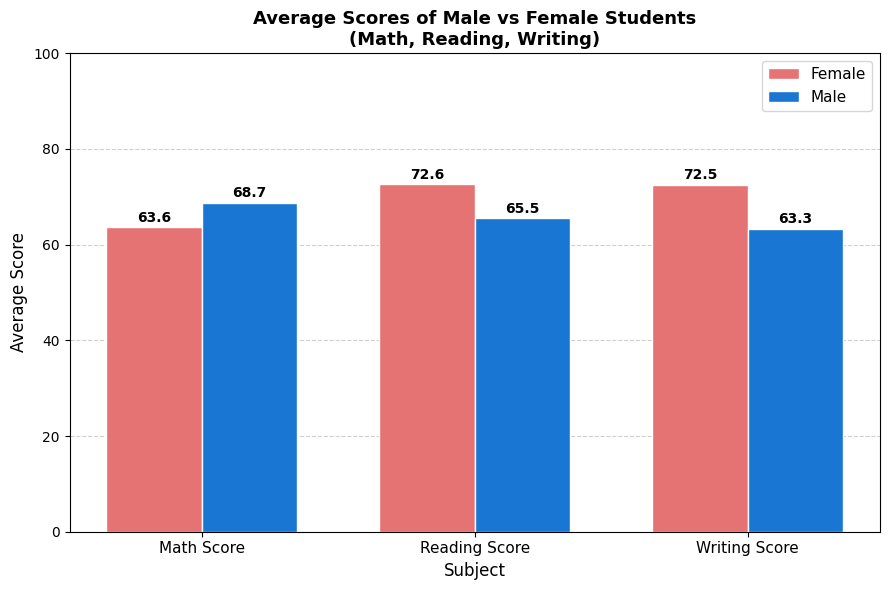

In [9]:
# --- Data Preparation ---
subjects = ['Math Score', 'Reading Score', 'Writing Score']

female_scores = gender_avg.loc['female'].values
male_scores   = gender_avg.loc['male'].values

x = np.arange(len(subjects))   # [0, 1, 2]
width = 0.35                    # width of each bar

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 6))

bars_female = ax.bar(x - width/2, female_scores, width,
                     label='Female', color='#E57373', edgecolor='white')

bars_male   = ax.bar(x + width/2, male_scores, width,
                     label='Male', color='#1976D2', edgecolor='white')

# --- Add value labels on top of each bar ---
for bar in bars_female:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars_male:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Labels & Formatting ---
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Average Score', fontsize=12)
ax.set_title('Average Scores of Male vs Female Students\n(Math, Reading, Writing)', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(subjects, fontsize=11)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('task2_gender_scores.png', dpi=150)   # Save the chart
plt.show()